In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
df = pd.read_csv("/customer_behavior.csv")

df.head()

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Gender           4903 non-null   object 
 2   Region           4825 non-null   object 
 3   PurchaseAmount   4850 non-null   float64
 4   ProductCategory  4474 non-null   object 
 5   Churn            4735 non-null   object 
 6   CampaignGroup    4815 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 273.6+ KB


,CustomerID,PurchaseAmount
count,5000.000000,4850.000000
mean,3500.500000,1003.950670
std,1443.520003,482.113122
min,1001.000000,0.000000
25%,2250.750000,673.642500
50%,3500.500000,998.080000
75%,4750.250000,1327.077500
max,6000.000000,2688.880000


Average, Median, and Mode of PurchaseAmount

In [ ]:
mean_purchase = df['PurchaseAmount'].mean()
median_purchase = df['PurchaseAmount'].median()
mode_purchase = df['PurchaseAmount'].mode()[0]

mean_purchase, median_purchase, mode_purchase

(np.float64(1003.9506701030928), 998.0799999999999, np.float64(0.0))

Are There Any Outliers in PurchaseAmount?

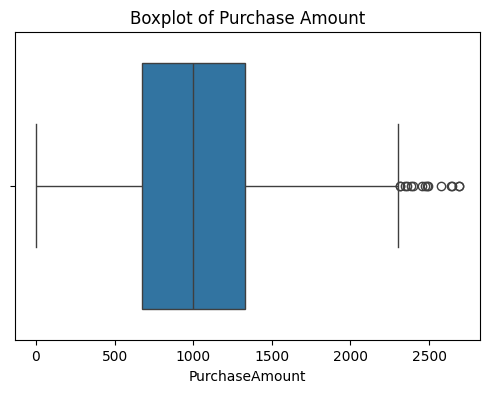

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['PurchaseAmount'])
plt.title("Boxplot of Purchase Amount")
plt.show()

In [ ]:
#IQR Method
Q1 = df['PurchaseAmount'].quantile(0.25)
Q3 = df['PurchaseAmount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['PurchaseAmount'] < lower_bound) | (df['PurchaseAmount'] > upper_bound)]
len(outliers)

15

Skewness and Kurtosis of PurchaseAmount

In [ ]:
skewness = stats.skew(df['PurchaseAmount'])
kurtosis = stats.kurtosis(df['PurchaseAmount'])

skewness, kurtosis

(np.float64(nan), np.float64(nan))

Skewness > 0 → Right-skewed
Skewness < 0 → Left-skewed
Kurtosis > 0 → Heavy tails (outliers present)

Difference in Spending Between Male and Female Customers

In [ ]:
df.groupby('Gender')['PurchaseAmount'].mean()

,PurchaseAmount
Gender,
Female,987.872046
Male,1019.176609


In [ ]:
#Independent T-Test
male = df[df['Gender'] == 'Male']['PurchaseAmount']
female = df[df['Gender'] == 'Female']['PurchaseAmount']

t_stat, p_value = stats.ttest_ind(male, female)

t_stat, p_value

(np.float64(nan), np.float64(nan))

If p-value < 0.05, spending difference is statistically significant.

Relationship Between ProductCategory and Churn

In [ ]:
#Contingency Table
contingency_table = pd.crosstab(df['ProductCategory'], df['Churn'])
contingency_table

Churn,No,Yes
ProductCategory,,
Electronics,785,541
Fashion,839,607
Grocery,855,604


In [ ]:
#Chi-Square Test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

chi2, p # p < 0.05 → Product category impacts churn behavior.

(np.float64(0.3960436652673918), np.float64(0.8203519424988512))

Does PurchaseAmount Vary Across Regions?

In [ ]:
#ANOVA Test
groups = [group['PurchaseAmount'].values for name, group in df.groupby('Region')]
f_stat, p_value = stats.f_oneway(*groups)
f_stat, p_value #p < 0.05 → Significant regional spending differences.

(np.float64(nan), np.float64(nan))

Campaign A vs B Performance

In [ ]:
campaign_avg = df.groupby('CampaignGroup')['PurchaseAmount'].mean()
campaign_avg

,PurchaseAmount
CampaignGroup,
A,1011.945587
B,994.339965


Campaign with higher average PurchaseAmount performed better

Useful for A/B testing decisions

Normality Test for PurchaseAmount

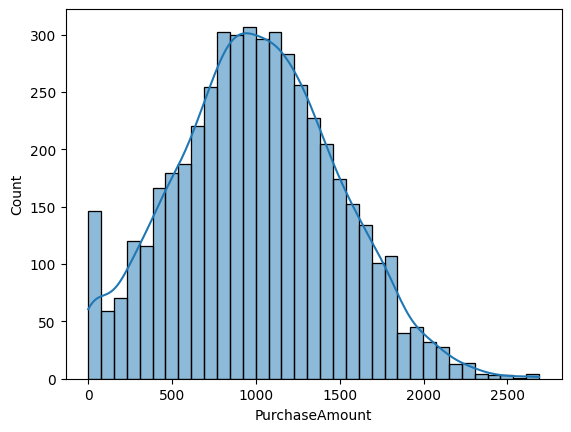

In [ ]:
#Histogram + KDE

sns.histplot(df['PurchaseAmount'], kde=True)
plt.show()

In [ ]:
#Shapiro-Wilk Test
stat, p_value = stats.shapiro(df['PurchaseAmount'].sample(500))
stat, p_value

(np.float64(nan), np.float64(nan))

p < 0.05 → Not normally distributed

Large datasets often violate normality

Central Limit Theorem (CLT) Insights

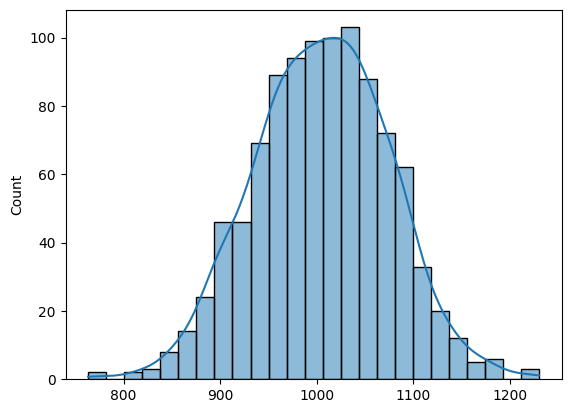

In [ ]:
sample_means = []
for _ in range(1000):
    sample = df['PurchaseAmount'].sample(50)
    sample_means.append(sample.mean())

sns.histplot(sample_means, kde=True)
plt.show()

95% Confidence Interval for Average PurchaseAmount

In [ ]:
mean = df['PurchaseAmount'].mean()
std = df['PurchaseAmount'].std()
n = df.shape[0]

z = stats.norm.ppf(0.975)

lower_ci = mean - z * (std / np.sqrt(n))
upper_ci = mean + z * (std / np.sqrt(n))

lower_ci, upper_ci

(np.float64(990.5874217139674), np.float64(1017.3139184922181))

We are 95% confident that the true average PurchaseAmount lies within this interval.